In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from composite_tools import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# Example parameters
K1 = 10e9
K2 = 30e9
G1 = 1e9
G2 = 10e9
eta1 = 1e17
eta2 = 1e7

In [9]:
phi2 = 0.01
num, den, G_inf = SphericalInclusion.G_pole_zero(K1, K2, G1, G2, eta1, eta2, phi2)

In [ ]:
# Positive coefficients (units of frequency)
c = -pole_zero_split(num, den)
# Positive frequencies
omega = -den
# Partition of unity
c / omega

array([0.95710451, 0.03538917, 0.00750631])

Platelet root identification

In [21]:
s1 = .5984
s2 = 123523

a = 9 * K2 + 8 * G2 + 12 * G1 + 6 * K2 * G1 / G2
b = 9 * K2 * (s1 + s2) + 8 * G2 * s1 + 12 * G1 * s2 + 12 * K2 * G1/ G2 * s2
c = 9 * K2 * s1 * s2 + 6 * K2 * G1 / G2 * s2 * s2

In [54]:
Qs0, Qs1 = np.roots([1, b/a, c/a])
num = np.array([0, -(G2 * s1 - G1 * s2) / (G2 - G1), Qs0, Qs1])
den = np.array([-s1, -s1, -s2, -15 * K2 * s2 / (15 * K2 + 20*G2)])
np.sort(num), np.sort(den)

(array([-95827.08053466,  -7542.71799166,      0.        ,  13724.11288889]),
 array([-1.23523000e+05, -8.55159231e+04, -5.98400000e-01, -5.98400000e-01]))

In [44]:
1, b/a, c/a

(1, 103369.79852631579, 722796644.4370105)

In [48]:
Qs0**2 + (b/a) * Qs0 + (c/a)

-1.1920928955078125e-06

In [49]:
a * Qs1 * Qs1 + b * Qs1 + c

0.0

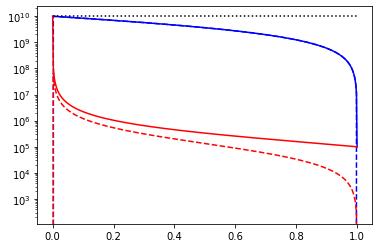

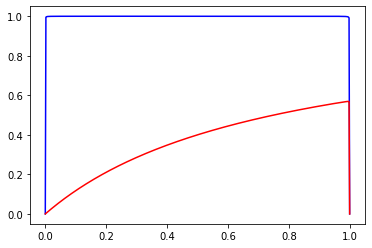

In [190]:
# K standard linear solid
# Example parameters
K1 = 10e9
K2 = 1e5 # 30e9
G1 = 10e9
G2 = K2 # Poisson ratio implicit
nu1 = (3 * K1 - 2 * G1) / (2 * (3 * K1 + G1))
nu2 = (3 * K2 - 2 * G2) / (2 * (3 * K2 + G2))
eta1 = 1e17
eta2 = 1e6
s1 = G1 / eta1
s2 = G2 / eta2

# Branch weight
M = lambda phi2: phi2 * (K2 - K1) **2 / (K2 * (K2 + (4/3)*G1)) * 4/3 * G1
# Elastic K_infty
K_infty = lambda phi2: K1 + phi2 * (K2 - K1) * (K1 + (4/3) * G1) / (K2 + (4/3) * G1)
K_min = lambda phi2: phi2 * K1 / K2 * (K2 - K1)
# Hashin type
def K_H_infty(phi2, K1, K2, G1,):
  return K1 + phi2 * (K2 - K1) * (K1 + (4/3) * G1) / (K1 + (4/3) * G1+ (1-phi2) * (K2-K1))
def K_H_relaxable(phi2, K1, K2, G1, s1):
  return phi2 * (1 - phi2) * (K2 - K1)**2 * ((4/3) * G1) \
    / ((K1 + (4/3) * G1+ (1-phi2) * (K2-K1)) * (K1 + (1-phi2) * (K2-K1)))
def relaxable_ratio(phi2, K1, K2, G1, s1):
  return K_H_relaxable(phi2, K1, K2, G1, s1) / K_H_infty(phi2, K1, K2, G1,)


phi2_range = np.linspace(0, 1, 500)

# relaxable_ratio = M(phi2_range) / K_infty(phi2_range)

plt.figure()
plt.semilogy(phi2_range, K_H_infty(phi2_range, K1, K2, G1), 'b')
plt.semilogy(phi2_range, K_H_relaxable(phi2_range, K1, K2, G1, -s1), 'b--')
plt.semilogy(phi2_range, np.full_like(phi2_range, K1), 'k:')

plt.plot(phi2_range, K_H_infty(1-phi2_range, K2, K1, G2), 'r')
plt.plot(phi2_range, K_H_relaxable(1-phi2_range, K2, K1, G2, -s2), 'r--')
# plt.plot(phi2_range, (1-phi2_range) * K1 * (4/3*G1) / (phi2_range*K1 + 4/3 * G1), 'g-.')

# plt.plot(phi2_range, K_infty(phi2_range))
# plt.plot(phi2_range, K_min(phi2_range))
# plt.plot(phi2_range, K_infty(phi2_range))
# plt.plot(phi2_range, relaxable_ratio)
# plt.ylim(0, 1)
# relaxable_ratio

plt.figure()
plt.plot(phi2_range, relaxable_ratio(phi2_range, K1, K2, G1, s1), 'b')
plt.plot(phi2_range, relaxable_ratio(phi2_range, K2, K1, G2, s2), 'r')


Text(0, 0.5, '$K_\\mathrm{relaxable} / K_1$')

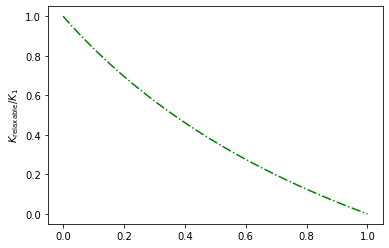

In [180]:
# K2 << K1 approx:
plt.plot(phi2_range, (1-phi2_range) * (4/3*G1) / (phi2_range*K1 + 4/3 * G1), 'g-.')
plt.ylabel("$K_\mathrm{relaxable} / K_1$")

In [ ]:
# Bounds

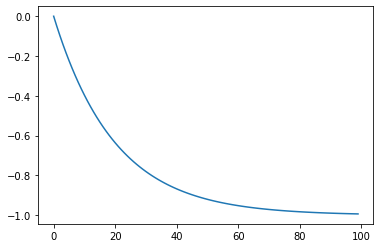

In [104]:
plt.plot(np.exp(-np.linspace(0,5,100)) - 1)


In [91]:
s1 = G1 / eta1
s1 = G1 / eta1
K_k = lambda s: K1 + phi2 * (K2 - K1) * (K1 + (4/3)*G1) / (K2 + (4/3)*G1) \
 - phi2 * (K2 - K1)**2 / (K2 + (4/3)*G1)**2 * ((4/3) * G1) * s1 / (s + K2 / (K2 + (4/3)*G1) * s1)


In [92]:
K_orig = lambda s: K1 + phi2 * (K2 - K1) * (3 * K1 + 4 * G1 * s / (s + s1)) / (3 * K2 + 4 * G1 * s / (s + s1))

In [100]:
np.linalg.norm(K_orig(s_range) - K_k(s_range))

1.1444091796875e-05

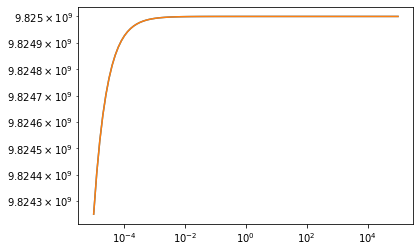

In [96]:
s_range = np.geomspace(1e-5, 1e5, 100)

plt.loglog(s_range, K_orig(s_range))
plt.loglog(s_range, K_k(s_range))

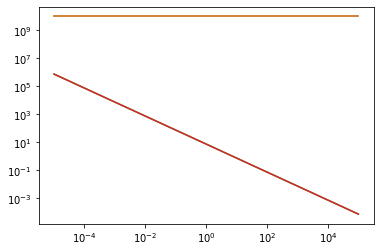

In [ ]:
s_range = np.geomspace(1e-5, 1e5, 100)

plt.loglog(s_range, np.real(K_orig(1j*s_range)))
plt.loglog(s_range, np.real(K_k(1j*s_range)))

plt.loglog(s_range, np.imag(K_orig(1j*s_range)))
plt.loglog(s_range, np.imag(K_k(1j*s_range)))

In [102]:
np.linalg.norm(np.imag(K_orig(1j*s_range)) - np.imag(K_k(1j*s_range)))


5.10779902513327e-10

In [191]:
def coeffs(K1, G1, G2, phi1, s1, s2):
  _t1 = 15-6*phi1
  _t2 = 20-12*phi1
  a = _t1 * K1 + _t2 * G1 + 6 * K1 * phi1 * G2 / G1 + 12 * G2  * phi1
  b = _t1 * K1 * (s1+s2) + _t2*G1*s2 + 12*K1*phi1*G2/G1*s1 + 12 * G2 * phi1 * s1
  c = _t1 * K1 * s1 * s2 + 6 * K1 * phi1 * G2 / G1 * s1 * s1
  return np.stack([a, b, c])

# Quadratic roots
def P2_roots(K1, G1, G2, phi1, s1, s2):
  ''' Vectorized quadratic roots '''
  _coeff = coeffs(K1, G1, G2, phi1, s1, s2)
  _coeff /= _coeff[0]
  sqrt_discriminant = np.sqrt(_coeff[1]**2 - 4 * _coeff[2])
  roots = np.stack([0.5 * (-_coeff[1] - sqrt_discriminant),
                    0.5 * (-_coeff[1] + sqrt_discriminant)])
  return roots

In [226]:
# Approximate roots
def P2_roots_approx(K1, G1, G2, phi1, s1, s2):
  ''' Vectorized quadratic roots '''
  nu1 = (3 * K1 - 2 * G1) / (2 * (3 * K1 + G1))
  factor = (1 - (2/5)*phi1) * (1 + nu1) / (3 * (1 - nu1) + 2 * phi1 * (nu1 - 4/5))
  roots = np.stack([-s2 * np.ones_like(phi1),
                    -s1 * factor])
  return roots

Text(0.5, 1.0, 'Spherical inclusion extension')

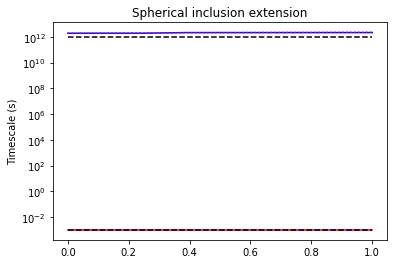

In [299]:
# Try reference parameters
(K1, G1, G2, phi1, s1, s2) = 1e9, 1e9, 1e5, 0.1, 1e-10, 1e5
(K1, G1, G2, phi1, s1, s2) = 1e10, 1e10, 1e5, 0.1, 1e-12, 1e3

# phi2_range = np.linspace(0,1,50)
phi2_range = np.geomspace(1e-10,1,50)
phi1_range = 1 - phi2_range
upper_root, lower_root = P2_roots(K1, G1, G2, phi1_range, s1, s2)
upper_root_approx, lower_root_approx = P2_roots_approx(K1, G1, G2, phi1_range, s1, s2)
plt.semilogy(1-phi1_range, -1/upper_root, 'r')
plt.semilogy(1-phi1_range, 1/np.full_like(phi1_range, s1), 'k--')
plt.semilogy(1-phi1_range, -1/upper_root_approx, 'm:')
plt.semilogy(1-phi1_range, -1/lower_root, 'b')
plt.semilogy(1-phi1_range, 1/np.full_like(phi1_range, s2), 'k--')
plt.semilogy(1-phi1_range, -1/lower_root_approx, 'm:')

plt.ylabel("Timescale (s)")
plt.title("Spherical inclusion extension")

Text(0.5, 1.0, 'Platelet inclusion extension')

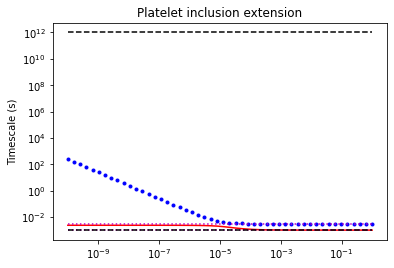

In [300]:
# Swapped coated sphere
# Try reference parameters
(K1, G1, G2, phi1, s1, s2) = 1e9, 1e9, 1e5, 0.1, 1e-10, 1e5
(K1, G1, G2, phi1, s1, s2) = 1e10, 1e10, 1e5, 0.1, 1e-12, 1e3

def P2_roots_approx_flipped_nondilute(K1, G1, G2, phi1, s1, s2):
  ''' With flipped roles, assuming phi2 * G1 / G2 '''
  nu1 = (3 * K1 - 2 * G1) / (2 * (3 * K1 + G1)) * np.ones_like(phi1)
  roots = np.stack([-np.ones_like(phi1),
                    -(1 + nu1) / (4 - 5*nu1)])
  return roots

flipped_phi2_range = np.geomspace(1e-10,1,50)
flipped_phi1_range = 1 - flipped_phi2_range
flipped_upper_root, flipped_lower_root = P2_roots(K2, G2, G1, 1-flipped_phi1_range, s2, s1)
flipped_upper_root_approx, flipped_lower_root_approx = s2 * (
  P2_roots_approx_flipped_nondilute(K2, G2, G1, 1-flipped_phi1_range, s2, s1))
plt.loglog(1-flipped_phi1_range, -1/flipped_upper_root, 'r')
plt.loglog(1-flipped_phi1_range, 1/np.full_like(flipped_phi1_range, s1), 'k--')
plt.loglog(1-flipped_phi1_range, -1/flipped_upper_root_approx, 'm:')
plt.loglog(1-flipped_phi1_range, -1/flipped_lower_root, 'b.')
plt.loglog(1-flipped_phi1_range, 1/np.full_like(flipped_phi1_range, s2), 'k--')
plt.loglog(1-flipped_phi1_range, -1/flipped_lower_root_approx, 'm:')

plt.ylabel("Timescale (s)")
plt.title("Platelet inclusion extension")


In black: phase Maxwell times 1/s1 and 1/s2
In red: spherical inclusion-like coated spheres (weak material inside)
In blue: platelet inclusion-like coated spheres (weak material outside)
Dots: coated sphere pole calculation
Line: asymptotic approximation of pole, where s2/s1 >> 1 AND:
  a) for red: G2/G1 << 1;
  b) for blue: G2/G1 << phi2)


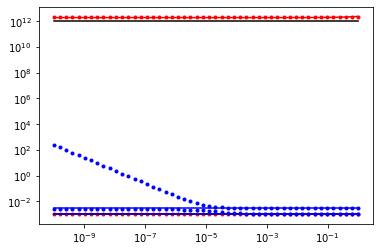

In [ ]:
plt.loglog(1-phi1_range, -1/upper_root, 'r.')
plt.loglog(1-phi1_range, 1/np.full_like(phi1_range, s1), 'k')
plt.loglog(1-phi1_range, -1/upper_root_approx, 'r-')
plt.loglog(1-phi1_range, -1/lower_root, 'r.')
plt.loglog(1-phi1_range, 1/np.full_like(phi1_range, s2), 'k')
plt.loglog(1-phi1_range, -1/lower_root_approx, 'r-')

plt.loglog(1-flipped_phi1_range, -1/flipped_upper_root_approx, 'b-')
plt.loglog(1-flipped_phi1_range, -1/flipped_upper_root, 'b.')
plt.loglog(1-flipped_phi1_range, -1/flipped_lower_root_approx, 'b-')
plt.loglog(1-flipped_phi1_range, -1/flipped_lower_root, 'b.')

print("In black: phase Maxwell times 1/s1 and 1/s2")
print("In red: spherical inclusion-like coated spheres (weak material inside)")
print("In blue: platelet inclusion-like coated spheres (weak material outside)")
print("Dots: coated sphere pole calculation")
print("Line: asymptotic approximation of pole, where s2/s1 >> 1 AND:")
print("  a) for red: G2/G1 << 1;")
print("  b) for blue: G2/G1 << phi2)")
print("Note there is also an explicit root at exactly s1 (for red) and s2 (for blue)")
print("Note there is also an explicit root at exactly s1 or s2")


For red (weak material inside the strong, like melt in a homogeneous crystalline shell), the timescales of viscoelasticity are simple, representing the relaxation of either phase, and a third, slower timescale related to the shell relaxation timescale
$$
s_3 = s_1 \left(1 - \frac{2}{5} \phi_1 \right) \frac{1 + \nu_1}{(3 (1 - \nu_1) + 2 \phi_1 (\nu_1 - 4/5))},
$$
where phase $1$ is the shell and phase $2$ is the melt.

For blue (strong material inside the weak, like melt surrounding a crystalline core), the timescales are more complicated. First, for $G_2 / G_1 \ll \phi_2$, all the timescales are concentrated near the fast relaxation timescale $1/s_2$; we verify this below with a complex sweep of the Hashin formula. On the other hand, for $G_2 / G_1 \gg \phi_2$ (for example by taking $\phi_2 \to 0$ for fixed choice of phasic material properties), the slow relaxation timescale $1/s_1$ is recovered.


In [315]:
s1

1e-12

(array([435.37736448,  37.44879071]), 1000.0)

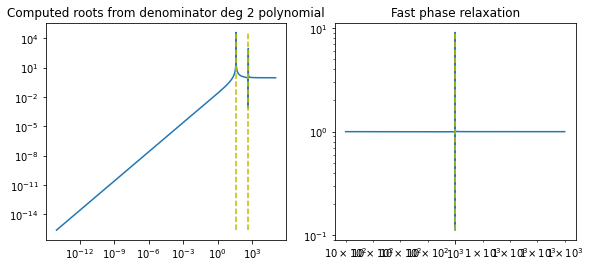

In [380]:
# Sweep for [blue] case: strong core, weak coating

def G_H(K2, G1, G2, phi2):
  return G2 + (G1 - G2) * (1-phi2) * (15 * K2 + 20 * G2) / (
    15 * K2 + 20 * G2 + 6 * (K2 + 2*G2) * (G1/G2 - 1) * phi2)

# Choice of phi2
phi2 = 1e-6

sweep = lambda s: G_H(K2, G1 * s / (s - s1), G2 * s / (s - s2), phi2)
# freq_range = np.geomspace(1e-4*s2, 1e4*s2, 20000)
freq_range = np.geomspace(.9999999*s2, 1.0000001*s2, 200000)
# Plot sweep
G_H_complex = sweep(freq_range)
plt.figure(figsize=(9.5,4))
plt.subplot(1,2,2)
plt.loglog(freq_range, np.abs(G_H_complex) / G1, '-')
# Vertical line option
vert_line = lambda x_value: plt.loglog([x_value, x_value],
  [np.abs(G_H_complex).min() / G1, np.abs(G_H_complex).max() / G1], 'y--')

vert_line(s2)
plt.title("Fast phase relaxation")

plt.subplot(1,2,1)
freq_range = np.geomspace(1e-2*s1, 1e2*s2, 200000)
# Plot sweep
G_H_complex = sweep(freq_range)
plt.loglog(freq_range, np.abs(G_H_complex) / G1, '-')
# Vertical line option
vert_line = lambda x_value: plt.loglog([x_value, x_value],
  [np.abs(G_H_complex).min() / G1, np.abs(G_H_complex).max() / G1], 'y--')

# Get roots from denominator
r1, r2 = -P2_roots(K2, G2, G1, phi2, s2, s1)

vert_line(r1)
vert_line(r2)
plt.title("Computed roots from denominator deg 2 polynomial")

-P2_roots(K2, G2, G1, phi2, s2, s1), s2

From the above sweep, we see the three poles correspond to the roots computed from the deg 2 denominator and the weaker phase's relaxation rate $s_2$.